# Model description
Below, a mesa implementation is given of Eppstein's Civil Violence model 1. The basic idea of this model is the following. We have 2 types of agents: cops and citizens. Cops and Citizens both have a field of vision and they move every step to a random empty location within their field of vision. The agents are all located on a toroidal grid and each grid cell can only be occupied by at most a single agent. 

*note: This assignment is adapted from previous exams. A typical exam would combine assignment 1 or 2 (i.e., implementing something within the model), with 3 or 4 (i.e., doing some experimentation with the model)*

## Citizen
Citizens can protest (i.e. becomes $active$). They decide every tick, after having moved, whether or not they want to protest (i.e., become active). They make this decision based on their attributes. 

- attributes with unique values for each citizen:
    - hardship, drawn from $U(0, 1)$
    - risk aversion, drawn from $U(0, 1)$
- attributes with shared values across all Citizens (i.e., class level attributes):
    - perception of the legitimacy of the State, a user specified parameter between 0 and 1. 
    - threshold above which Citizens will protest, a user specified parameter usually set to a small positive value (e.g., 0.1).

An agent becomes active if: (Grievance - Net Risk) > Threshold. Otherwise the agent is $quiet$.

**Grievance** is calculated for each citizen as: 

$
    grievance = hardship * (1-legitimacy)
$

The **net risk** is the perceived chance of being arrested times the personal level of risk aversion. The perceived chance of being arrested is given by

$
    p = 1 - e^{(-1*k*round(c/a))}
$

Where:
- $k$ is an arrenst probability constant (set to 2.3 as default), 
- $c$ is the number of cops within the field of vision,
- $a$ is the number of active citizens within the field of vision including the agent itself (who considers herself always active).

So the net risk is:

$
net\_risk = p * risk\_aversion
$

## Cop
After having moved, the cop checks his field of vision for any active citizens. It then arrests a randomly selected active citizen within its field of vision. 

## Arrest
If a citizen is arrested, it cannot move. Upon arrest, a citizen also receives a random jail time, which is the number of ticks for which it remains under arrest. Jail time is drawn from $U(U, J_{max})$, where $J_{max}$ is a user specified parameter which can substantially alter the dynamics of the model. 

# Implementation details.
The model below is an implementation of the civil violence model. Given that the movement behavior and the way in which agents update their field of vision is the same for both Citizens and Cops, this functionality is implemented in a BaseAgent class. The Cop class and Citizen class both extend this BaseAgent class and add their respective behavior to it. The model itself uses a von Neumann toroidol space with maximum 1 agent per grid cell. Class level attributes are used for legitimacy, vision, $k$, and activation threshold. 

# Assignment 1
Given the description above and the provided implementation below, complete the model `__init__` function. The expected results are shown in the figure and you can use the provided plotting code to generate your results.

<div>
<img src="results.png" width="600"/>
</div>

In [10]:
import math
from enum import Enum

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable

from mesa import Model, Agent
from mesa.datacollection import DataCollector
from mesa.experimental.cell_space import OrthogonalVonNeumannGrid, CellAgent


class CitizenState(Enum):
    ACTIVE = 1    
    QUIET = 2    
    ARRESTED = 3


class CivilViolence(Model):
    """Model class for Eppstein's Civil Violence model I.
    
    The initial values are from Eppstein's article.
    """

    def __init__(self, height=40, width=40, citizen_density=0.7, citizen_vision=7,
        legitimacy=0.82, activation_treshold=0.1, arrest_prob_constant=2.3,
        cop_density=0.04, cop_vision=7, max_jail_term=15, seed=None):
        super().__init__(seed=seed)
        
        # can be checked because densities are provided by modeler as input and known at this point
        assert (citizen_density+cop_density) < 1
        
        # setup Citizen class attributes
        Citizen.vision = citizen_vision
        Citizen.legitimacy = legitimacy
        Citizen.arrest_prob_constant = arrest_prob_constant
        Citizen.activation_threshold = activation_treshold
        
        # setup Cop class attributes
        Cop.vision = cop_vision
        Cop.max_jail_term = max_jail_term


        # Set up agents        
        self.grid = OrthogonalVonNeumannGrid((width, height), capacity=1,
                                        torus=True, random=self.random)
        n_cells = width * height #new avriable to accoutn for the known measurements of the grid which are eidth and height, NOT size
        n_cops = int(cop_density * n_cells)
        n_citizens = int(citizen_density * n_cells)
        
        #initializing an agent per cell according to densities
        for cell in self.grid.all_cells:
            kind = self.random.choices(
                [Cop, Citizen, None],
                cum_weights=[cop_density, cop_density + citizen_density, 1.0],
            )[0]
            #if kind == None then cell remains empty 
            if kind is not None:
                kind(self).cell = cell
        
        
        # setup data collection
        self.ACTIVE = 0
        self.ARRESTED = 0
        self.QUIET = 0
        
        model_reporters = {'active': CitizenState.ACTIVE.name,
                           'quiet': CitizenState.QUIET.name,
                           'arrested': CitizenState.ARRESTED.name}
        self._update_counts()
        self.datacollector = DataCollector(model_reporters=model_reporters)
        self.datacollector.collect(self)

    def _update_counts(self):
        for state, count in self.agents_by_type[Citizen].groupby("state").count().items():
            setattr(self, state.name, count)
        
    def step(self):
        """
        Run one step of the model.
        """
        self.agents.shuffle_do("step")
        self._update_counts()        
        self.datacollector.collect(self)

#BaseAgent is the general person agent that mvoes, and cops and citizens are subclasses
class BaseAgent(CellAgent):
    '''Base Agent class implementing vision and moving
    
    Attributes
    ----------
    moore : boolean
    
    '''    
    
    def get_agents_in_vision(self):
        """
        identify cops and active citizens within vision
        
        Returns
        -------
        tuple with list of cops, and list of active citizens
        
        """
        cops = []
        active_citizens = []
        
        for agent in self.cell.get_neighborhood(radius=self.__class__.vision).agents:
            if isinstance(agent, Cop):
                cops.append(agent)
            elif agent.state == CitizenState.ACTIVE:
                active_citizens.append(agent)    
        return cops, active_citizens
    
    def move(self):
        """Identify all empty cells within vision and move to a randomly selected one."""
        empty = [cell for cell in self.cell.get_neighborhood(radius=self.__class__.vision) 
                 if cell.is_empty]
        
        if empty:
            self.cell = self.random.choice(empty)
        
        
    
class Citizen(BaseAgent):
    '''Citizen class
    
    Attributes
    ----------
    legitimacy : boolean
    vision : int
    arrest_prob_constant : float
    activation_treshold : float
    hardship : float
    risk_aversion : float
    state : {CitizenState.QUIET, CitizenState.ACTIVE, CitizenState.ARRESTED }
    jail_time_remaining  :int
    grievance : float
    
    '''     
    
    #nominating the paramters here as well avoids attribute errors if someone instantiates Citizen outside the model setup
    #these parameters will be overrun by the model whe set up
    legitimacy = 1
    vision = 1
    arrest_prob_constant = 1
    activation_treshold = 1
    
    #here the model given paramters are extracted and the unique attributes of each citizen are initialized
    def __init__(self, model):
        super().__init__(model)
        #effectively equivelent to drawing from U(0, 1)
        self.hardship = self.random.random()
        self.risk_aversion = self.random.random()
        self.state = CitizenState.QUIET
        self.jail_time_remaining = 0
        self.grievance = self.hardship*(1-Citizen.legitimacy)


    def _check_jail_time(self):
        if (self.state == CitizenState.ARRESTED) and (self.jail_time_remaining > 0):
            self.jail_time_remaining -= 1
        return self.jail_time_remaining

    
    def step(self):
        """
        move and then decide whether to activate
        """
        
        if self._check_jail_time() > 0:
            return
            
        self.move()
            
        cops, active_citizens = self.get_agents_in_vision()
        n_cops = len(cops)
        n_active_citizens = len(active_citizens) + 1 # self is always considered active
            
        arrest_p = 1 - math.exp(-1*Citizen.arrest_prob_constant * round(n_cops/n_active_citizens))
        net_risk = self.risk_aversion * arrest_p
        
        if (self.grievance - net_risk) > self.activation_threshold:
            self.state = CitizenState.ACTIVE
        else:
            self.state = CitizenState.QUIET
        

class Cop(BaseAgent):
    '''Cop class
    
    Attributes
    ----------
    vision : int
    max_jail_term : int
    '''
    vision = 1
    max_jail_term = 1
        
    def step(self):
        self.move()
        # ignore cops, keep active citizens
        _, active_citizens = self.get_agents_in_vision()
        
        if active_citizens:
            citizen = self.random.choice(active_citizens)
            citizen.state = CitizenState.ARRESTED
            citizen.jail_time_remaining = self.random.randint(0, Cop.max_jail_term)

            
def visualize_model(model):
    sns.set_style('white')
    colors = sns.color_palette()[0:4]
    
    # if the plot is not nice given your window size
    # consider changing figsize, but keep the ratio intact
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 20))
    divider = make_axes_locatable(ax2)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    
    positions = []
    color_type = []
    grievance_level = []
    
    for cell in model.grid.all_cells:
        if cell.is_empty:
            continue
        
        positions.append(cell.coordinate)
        agent = cell.agents[0]
        if isinstance(agent, Citizen):
            color_type.append(colors[agent.state.value])
            grievance_level.append(agent.grievance)
        else:
            color_type.append(colors[0])
            grievance_level.append(np.nan) #dirty hack for masking
    
    positions = np.asarray(positions)
    
    ax1.scatter(positions[:, 0], positions[:, 1], s=15, c=color_type)
    im = ax2.scatter(positions[:, 0], positions[:, 1], s=15, c=grievance_level)
    
    for ax in (ax1, ax2):
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(im, cax=cax, orientation='vertical')
    
    ax1.set_title('Agent states')
    ax2.set_title('grievance view')

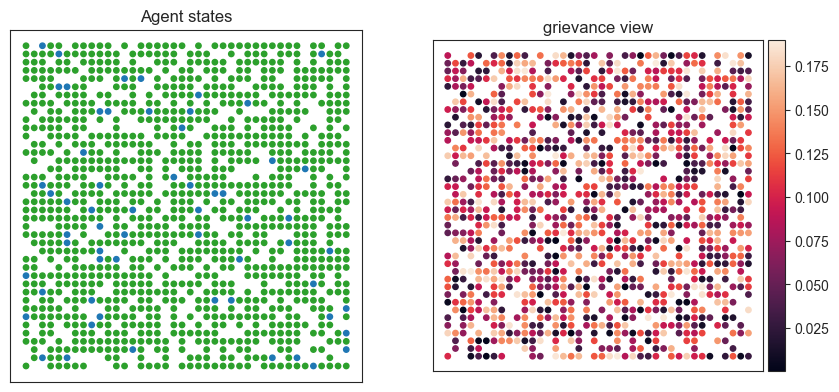

In [7]:
model = CivilViolence(cop_vision=7, citizen_vision=7, legitimacy=0.81,
                      max_jail_term=30, cop_density=0.04, citizen_density=0.7,
                      seed=123456789) #notice this time we set a seed to ensure reproducibility of results 
visualize_model(model)
for _ in range(500):
    model.step()

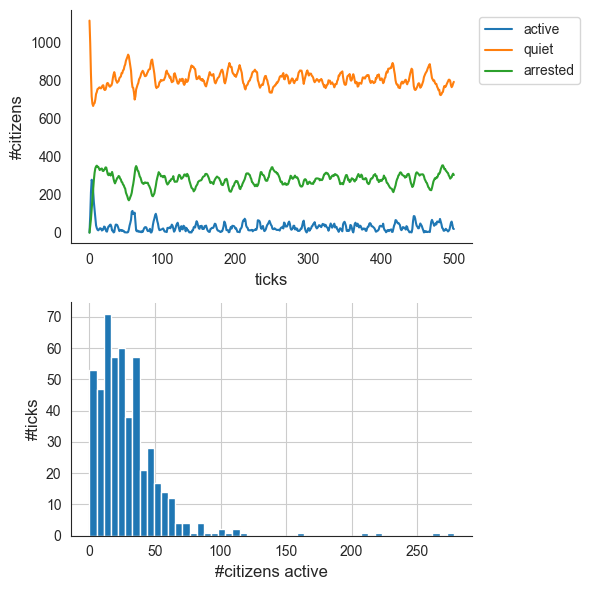

In [8]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(6, 6))

data = model.datacollector.get_model_vars_dataframe()
data.plot(ax=ax1)
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax1.set_xlabel('ticks', fontsize=12)
ax1.set_ylabel('#citizens', fontsize=12)

data.active.hist(bins=51, ax=ax2)
ax2.set_xlabel('#citizens active', fontsize=12)
ax2.set_ylabel('#ticks', fontsize=12)

sns.despine()
plt.tight_layout()

# save_fig(fig, '.', 'expected_results')

plt.show()


# Assignment 2
The original paper does not use the round operator in the calculation of the arrest probability. Instead, it just uses the raw ratio of number of cops within the field of vision to the number of active citizens within the field of vision. The problem is that if you follow the original paper, none of the reported dynamics can successfully be replicated. By now, there is quite a literature on this equation which is exploring alternative formulations for calculating the arrest probability. Modify the model to reflect the equation reported in Epstein (2002). That is, change round(cops/active citizens) to just cops/active citizens. Visually show the change in behaviour and explain your results.


In [11]:
# Save original step so we can restore later
orig_step = Citizen.step
"""
How is this patch not overrun by the orignial stepping method? 

    Python loads class Citizen with original step.
    You run Citizen.step = step_no_round -> pointer now points to new       function.
    You create CivilViolence(...). __init__ sets parameters, creates        agents, but does not change the step pointer.
    During model.step(), scheduler calls agent.step() for each citizen ->   it uses patched step_no_round.
    If you later restore Citizen.step = orig_step, new runs use original    logic again.

"""
def step_no_round(self):
    if self._check_jail_time() > 0:
        return

    self.move()
    cops, active_citizens = self.get_agents_in_vision()
    n_cops = len(cops)
    n_active_citizens = len(active_citizens) + 1  # include self

    # Epstein (2002): no round()
    arrest_p = 1 - math.exp(-Citizen.arrest_prob_constant * (n_cops / n_active_citizens))
    net_risk = self.risk_aversion * arrest_p

    self.state = (
        CitizenState.ACTIVE
        if (self.grievance - net_risk) > self.activation_threshold
        else CitizenState.QUIET
    )

Citizen.step = step_no_round

In [12]:
# 2) create model
model = CivilViolence(
    cop_vision=7, citizen_vision=7, legitimacy=0.81,
    max_jail_term=30, cop_density=0.04, citizen_density=0.7, seed=123456789
)

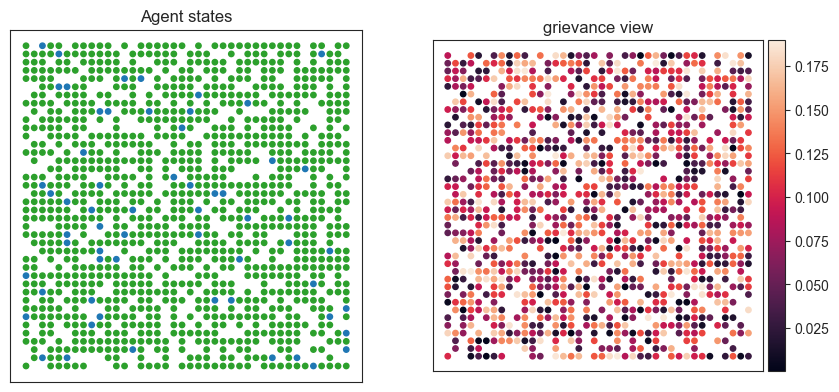

In [13]:
# 3) visualize + run
visualize_model(model)
for _ in range(500):
    model.step()

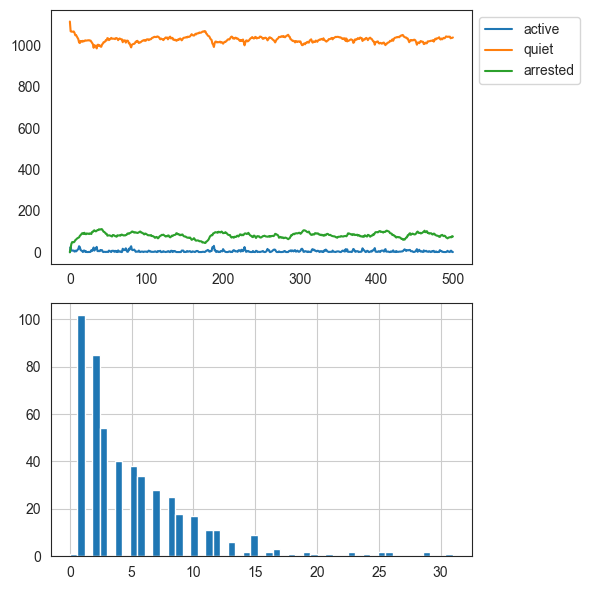

In [14]:
# 4) same plotting cell as before
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(6, 6))
data = model.datacollector.get_model_vars_dataframe()
data.plot(ax=ax1)
ax1.legend(bbox_to_anchor=(1, 1), loc='upper left')
data.active.hist(bins=51, ax=ax2)
plt.tight_layout()
plt.show()


I would assume the non-rounded implementation creates a much more nuanced world in which citizens can be active to varying degrees and the arrest probability can take on a much wider range of values, but the results are much more binary. This is a good example of how a small but non-zero deterrent (for example a 0.20 probability of arrest) can end up supressing the behaviour of a high number of citizens. 


# Assignment 3
The model is quite sensitive to the perceived risks of becoming active. Explore the dynamics of the model by varying the jail time. Specifically, how does the behaviour of the model change between a jail time of 5, 15, and 30 years? Visually show the change in behaviour and explain your results.


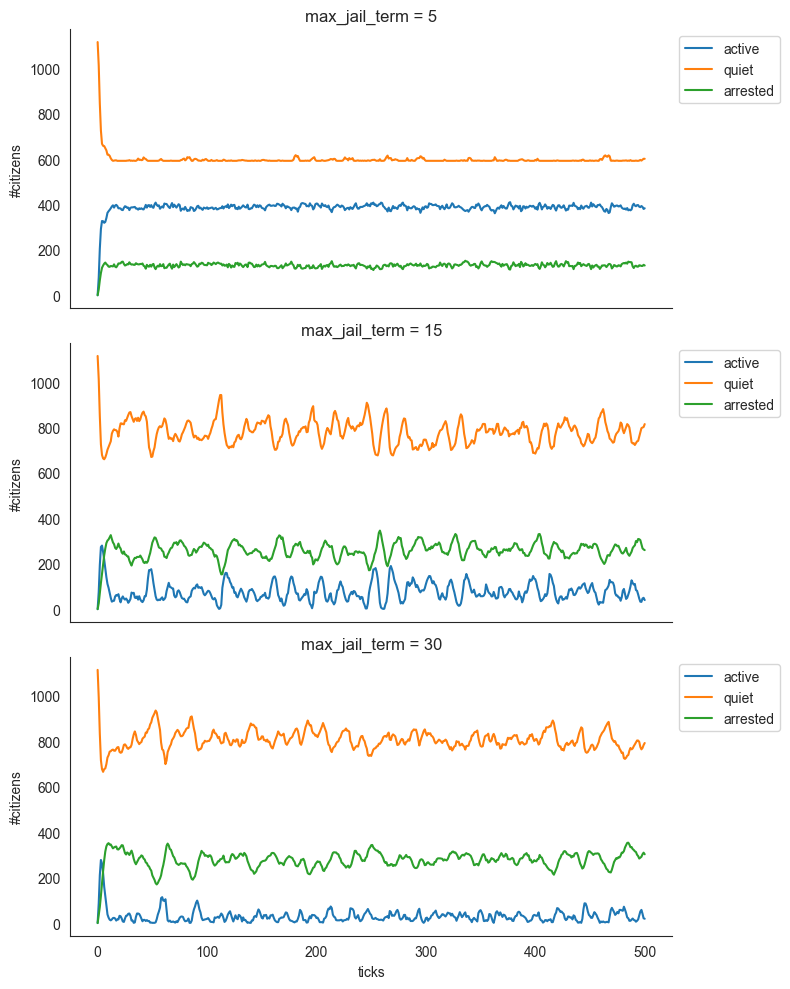

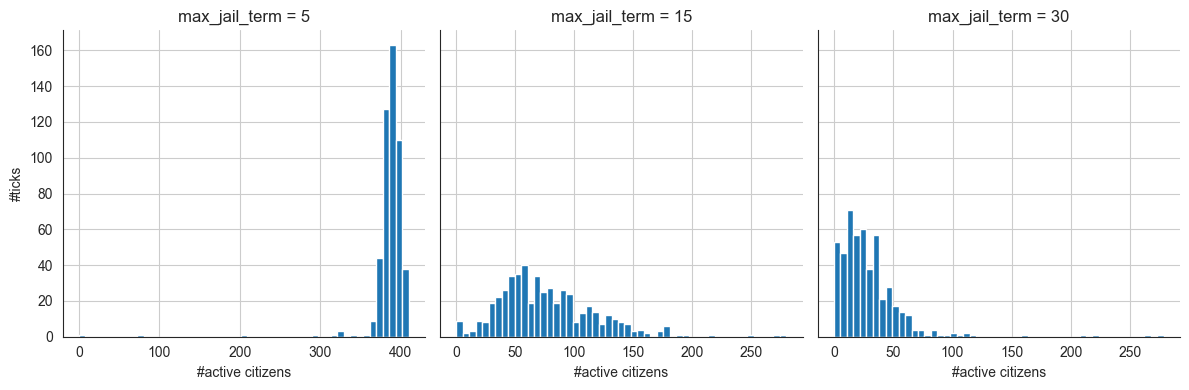

In [16]:
# restore original Citizen.step patched in Assignment 2
Citizen.step = orig_step

jail_times = [5, 15, 30]
results = {}

for jt in jail_times:
    m = CivilViolence(
        cop_vision=7, citizen_vision=7, legitimacy=0.81,
        max_jail_term=jt, cop_density=0.04, citizen_density=0.7,
        seed=123456789
    )
    for _ in range(500):
        m.step()
    results[jt] = m.datacollector.get_model_vars_dataframe()

# --- time series ---
fig, axes = plt.subplots(nrows=3, figsize=(8, 10), sharex=True, sharey=True)

for ax, jt in zip(axes, jail_times):
    results[jt].plot(ax=ax)
    ax.set_title(f'max_jail_term = {jt}')
    ax.set_ylabel('#citizens')
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

axes[-1].set_xlabel('ticks')
sns.despine()
plt.tight_layout()
plt.show()

# --- active-citizen histogram comparison ---
fig, axes = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for ax, jt in zip(axes, jail_times):
    results[jt]['active'].hist(bins=51, ax=ax)
    ax.set_title(f'max_jail_term = {jt}')
    ax.set_xlabel('#active citizens')

axes[0].set_ylabel('#ticks')
sns.despine()
plt.tight_layout()
plt.show()

The first observation is aligned with expectaitons, and that is that when the least amount of jail time is applied to the model, we see the most amount of active citizens, therefore we see a skewed histogram with a uniform peak around 380 citizens. The more we increase the jail time, the more the hsitogram shifts to the left, at the extreme 30 years jailtime seeing a concentration of active citizens around 0. It's interested to see that even though the histogram shifts to the left between 15 and 30 years of jalotime, from the nubmer of arrests in the plot we notice that this later mention paramter actually stays quite similar. This implies that cops no longer have who to arrest after a certain point.

Another surprising factor for me is that the longer jail time introduces more fluctuations in the graphs than the 5 year jail time. I was expeting a shorter jail time would mean a faster rate of change between agents being quite/arrested/active. This could indicate that maybe the neighbourhood selection is not so sensitive to short-term changes as it is to long-term changes, but this is just a speculation.

### Epstein observation
The fluctuations with longer jail time are the central finding of Epstein (2002) and are well understood: when a wave of citizens is arrested simultaneously, they are all released simultaneously after the same jail term. This synchronized release floods the grid with newly-free citizens at the same moment, triggering the next wave. Short jail time staggers releases, smoothing the dynamics. This is called punctuated equilibrium — not a neighborhood sensitivity effect. It's the core reason the paper argues that harsh sentencing can increase long-run volatility rather than suppress it.

# Assignment 4
The default setup of the model uses a fixed ratio of 70% agents, and 4% cops, leaving 26% of the grid cells empty. After the storming of the United States capital, people compared the mass presence of cops at the Black Lives Matter protests with the lack of presence on January 6 when Trump supporters were protesting. We can use the model to investigate whether this might have made a difference. How does the behaviour of the model change if we move from 2% cops to 4% or 6% cops? In answering this question, ensure that at all times 26% of your grid cells remains empty. Visually show the change in behaviour and explain your results. 

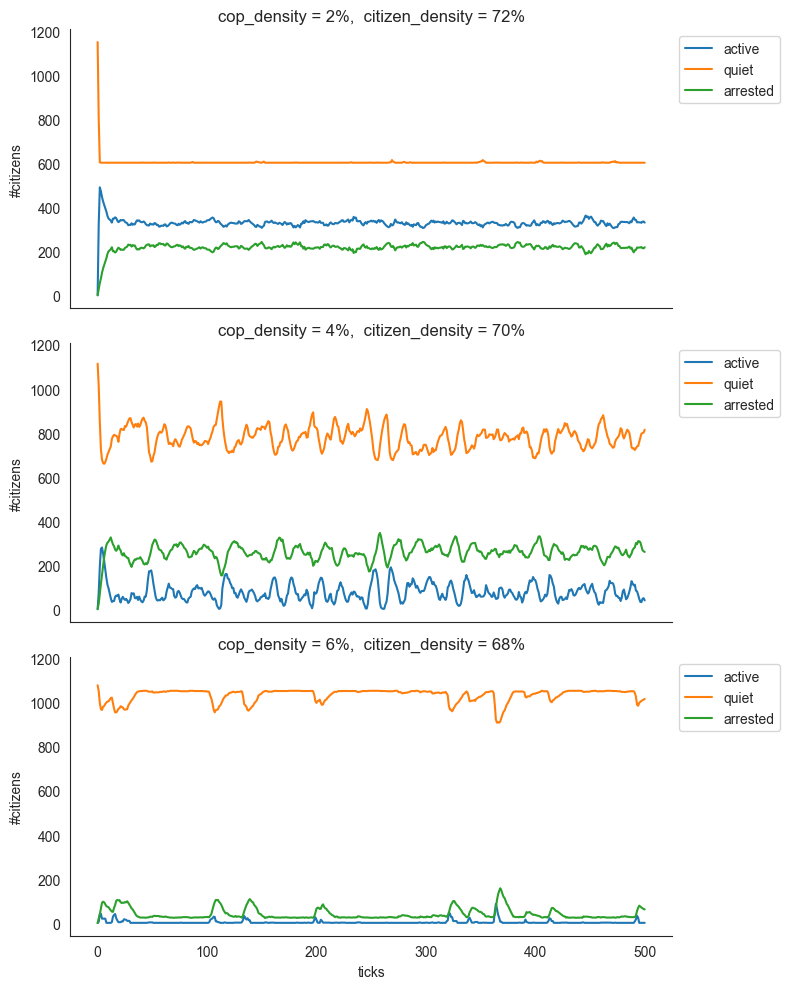

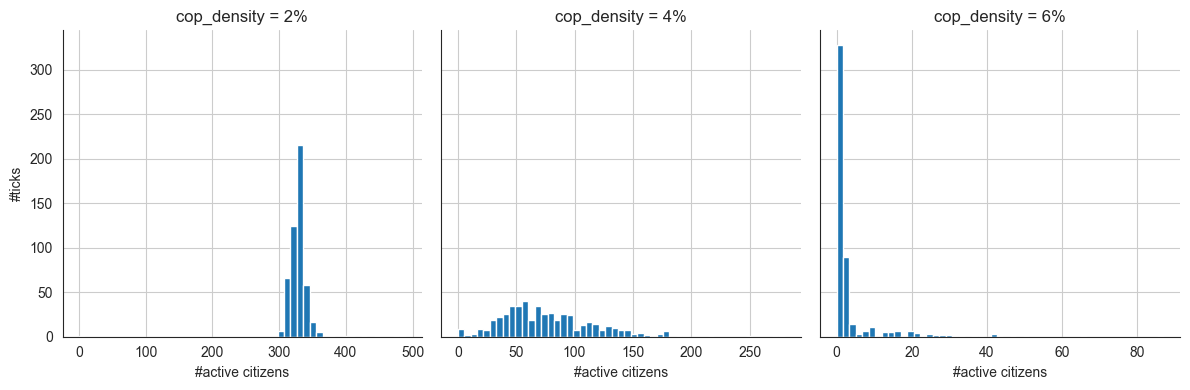

In [17]:
cop_densities = [0.02, 0.04, 0.06]
# citizen_density absorbs the difference so empty cells stay at 26%
results_4 = {}

for cd in cop_densities:
    citizen_density = 0.74 - cd  # 1 - 0.26 - cop_density
    #ensures cop + citizen = 0.74, leaving exactly 0.26 of cells empty regardless of cop density.
    m = CivilViolence(
        cop_vision=7, citizen_vision=7, legitimacy=0.81,
        max_jail_term=15, cop_density=cd, citizen_density=citizen_density,
        seed=123456789
    )
    for _ in range(500):
        m.step()
    results_4[cd] = m.datacollector.get_model_vars_dataframe()

# --- time series ---
fig, axes = plt.subplots(nrows=3, figsize=(8, 10), sharex=True, sharey=True)

for ax, cd in zip(axes, cop_densities):
    results_4[cd].plot(ax=ax)
    ax.set_title(f'cop_density = {cd:.0%},  citizen_density = {0.74 - cd:.0%}')
    ax.set_ylabel('#citizens')
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

axes[-1].set_xlabel('ticks')
sns.despine()
plt.tight_layout()
plt.show()

# --- active-citizen histogram ---
fig, axes = plt.subplots(ncols=3, figsize=(12, 4), sharey=True)

for ax, cd in zip(axes, cop_densities):
    results_4[cd]['active'].hist(bins=51, ax=ax)
    ax.set_title(f'cop_density = {cd:.0%}')
    ax.set_xlabel('#active citizens')

axes[0].set_ylabel('#ticks')
sns.despine()
plt.tight_layout()
plt.show()

big difference
